In [3]:
import pandas as pd
import numpy as np
import hist
import matplotlib as mpl
import mplhep
#import mplhep.error_estimation will come back to this later
mpl.style.use(mplhep.style.ROOT)
import matplotlib.pyplot as plt
import scipy
from scipy import optimize
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
import yaml
from statistics import mean 

In [4]:
pedestal = pd.read_csv('default_pedestal_10k.csv')

In [5]:
# define a unique ID for each channel to make histograms a bit easier to make
pedestal['uid'] = pedestal['i_link'].astype(str)+'_'+pedestal['channel']

In [6]:
def fill_and_plot_all_channels(
    xname, xlabel, xmin, xmax, rebin=1
):
    plt.figure(figsize=(20,10))
    (
        hist.Hist.new
        .StrCategory(pedestal['uid'].unique(), label='Link_Channel')
        .Reg((xmax-xmin)//rebin,xmin,xmax, label=xlabel)
        .Double()
    ).fill(
        pedestal['uid'],
        pedestal[xname]
    ).plot2d(
        cmin=1,
        cbarsize=0.7
    )
    plt.xticks(rotation=90, size='x-small')
    plt.show()

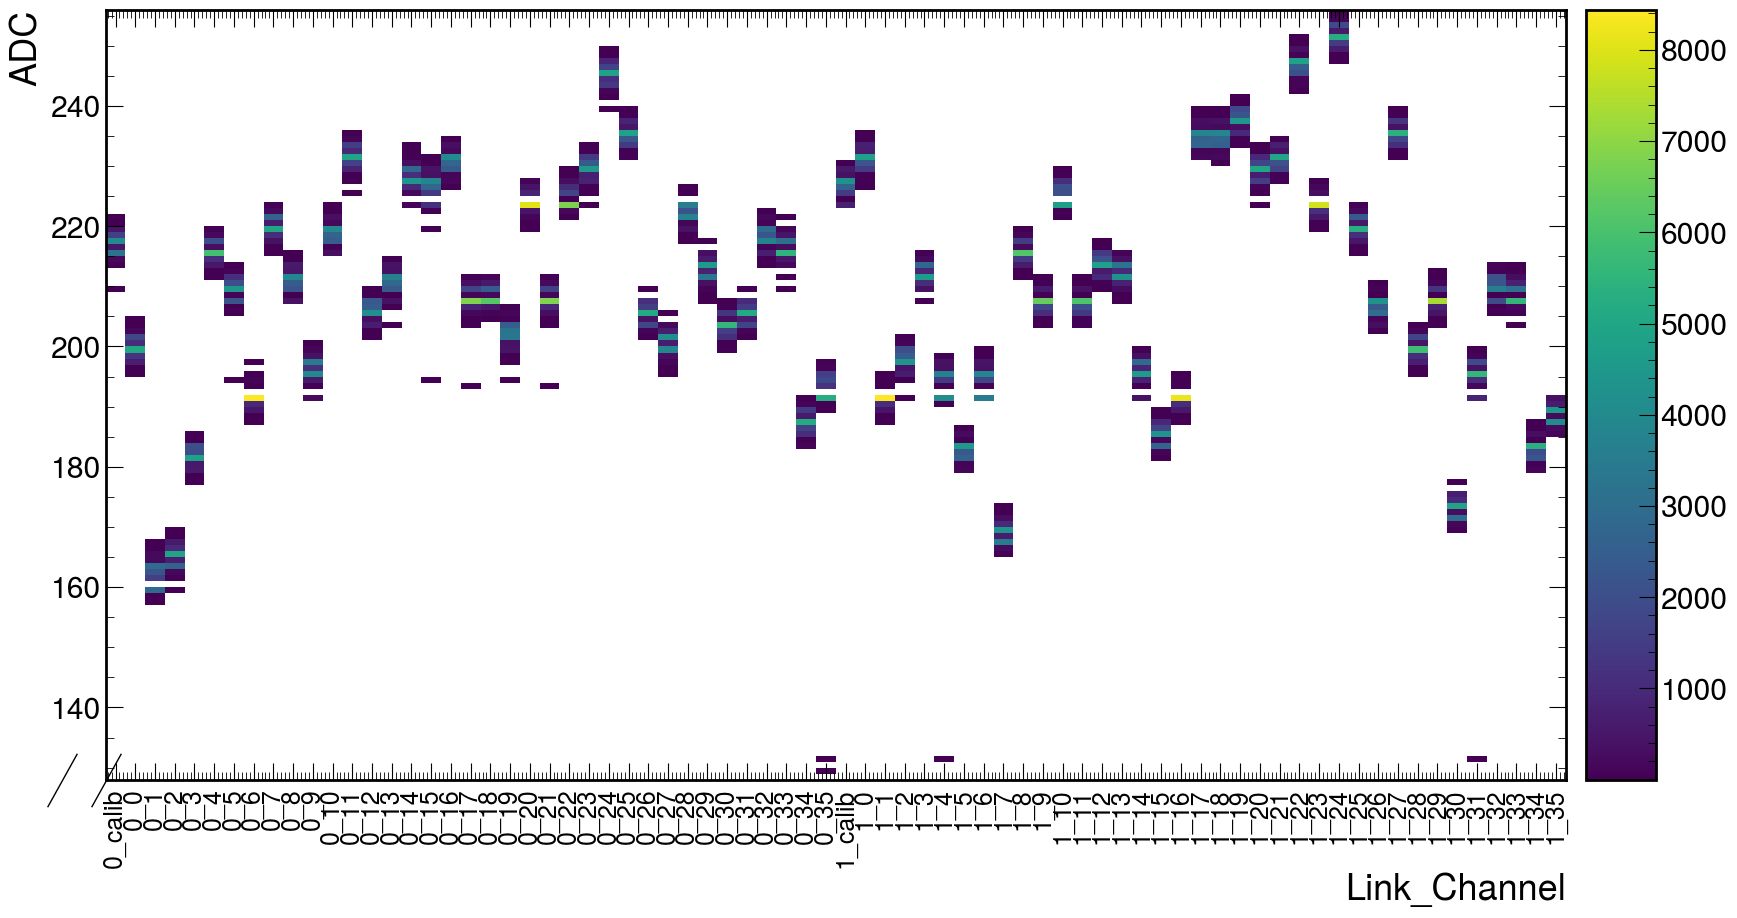

In [7]:
#general ADC Plot #128.256
fill_and_plot_all_channels('adc','ADC',128,256)

In [8]:
link_0 = pedestal[pedestal['i_link'] ==0] # separated the pedestal run by the two link channels - the two halves seen in HGCROC Tuning slides
link_1 = pedestal[pedestal['i_link'] ==1]


In [9]:

link_0.describe() #looking at the new arrays generated

,i_link,bx,event,orbit,adc_tm1,adc,tot,toa
count,370000.0,370000.0,370000.000000,370000.000000,370000.000000,370000.000000,370000.0,370000.0
mean,0.0,14.0,31.496700,3.508800,209.544727,209.532405,-1.0,0.0
std,0.0,0.0,18.470737,2.290357,17.688148,17.690399,0.0,0.0
min,0.0,14.0,0.000000,0.000000,131.000000,129.000000,-1.0,0.0
25%,0.0,14.0,16.000000,2.000000,201.000000,201.000000,-1.0,0.0
50%,0.0,14.0,31.000000,4.000000,210.000000,210.000000,-1.0,0.0
75%,0.0,14.0,47.250000,6.000000,223.000000,223.000000,-1.0,0.0
max,0.0,14.0,63.000000,7.000000,249.000000,249.000000,-1.0,0.0


In [10]:
link_0_norm =link_0[link_0['channel'] != 'calib'] # removed the calibration channels to assess means/medians
link_1_norm =link_1[link_1['channel'] != 'calib']

Text(0.5, 1.0, 'Link 0')

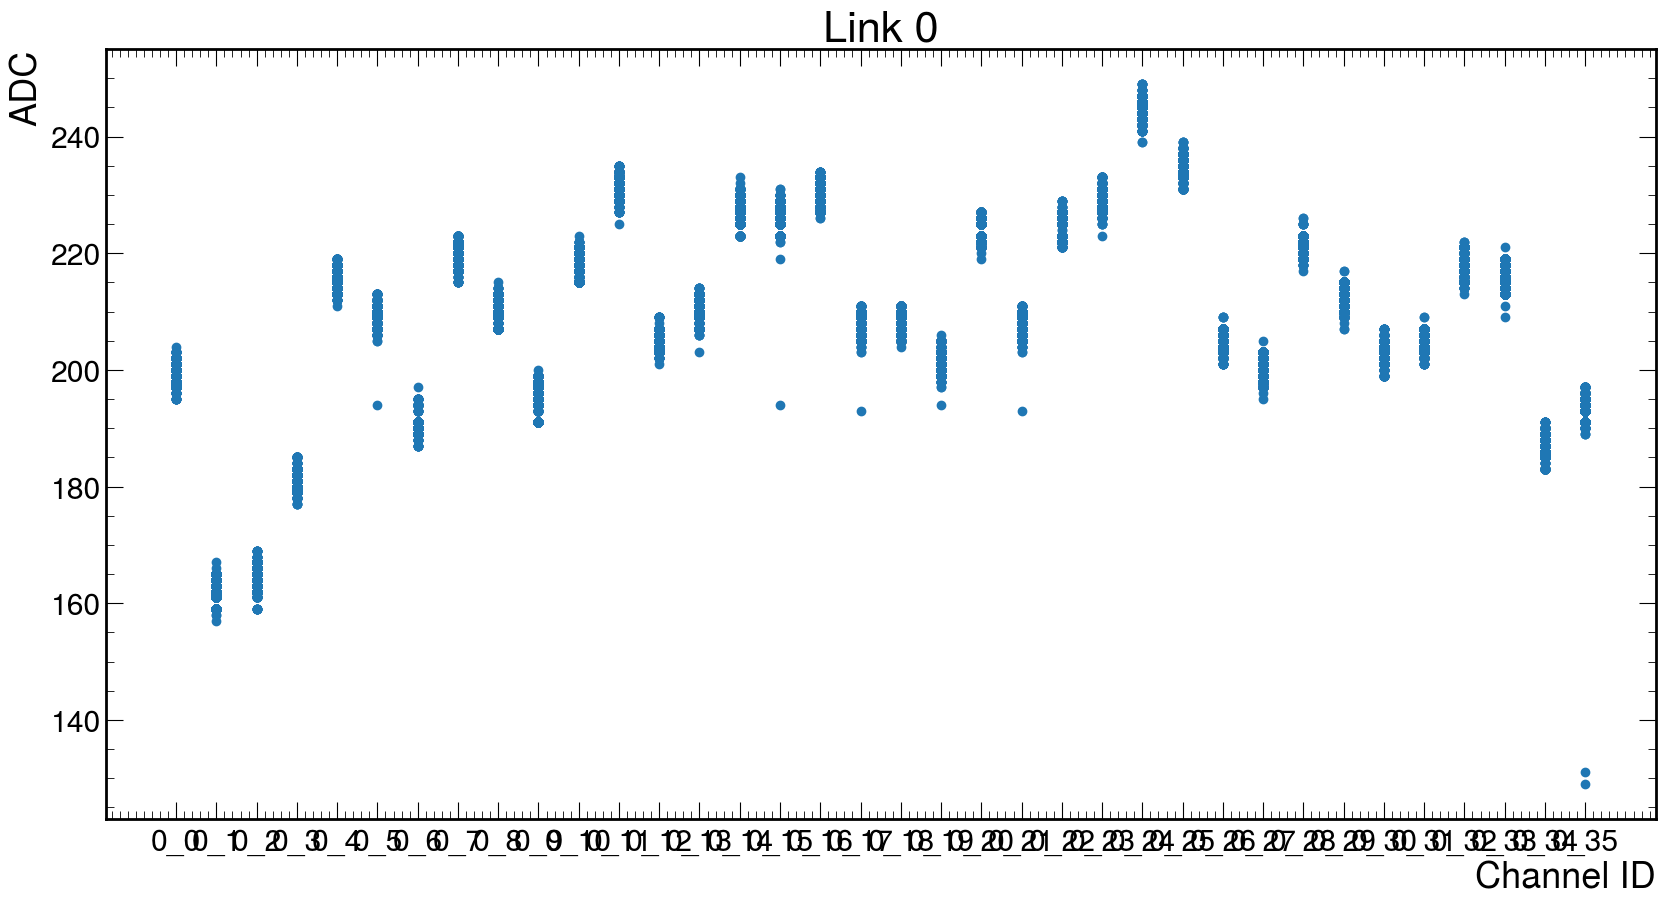

In [11]:
plt.figure(figsize=(20,10))
plt.scatter(link_0_norm.uid,link_0_norm.adc)
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 0")

In [12]:
print ("Link 0 median ADC is " + str(link_0_norm['adc'].median()) + " without calibration channels")
print ("Link 0 mean ADC is " + str(link_0_norm['adc'].mean()) + " without calibration channels")



Link 0 median ADC is 209.0 without calibration channels
Link 0 mean ADC is 209.33851944444444 without calibration channels


Text(0.5, 1.0, 'Link 0')

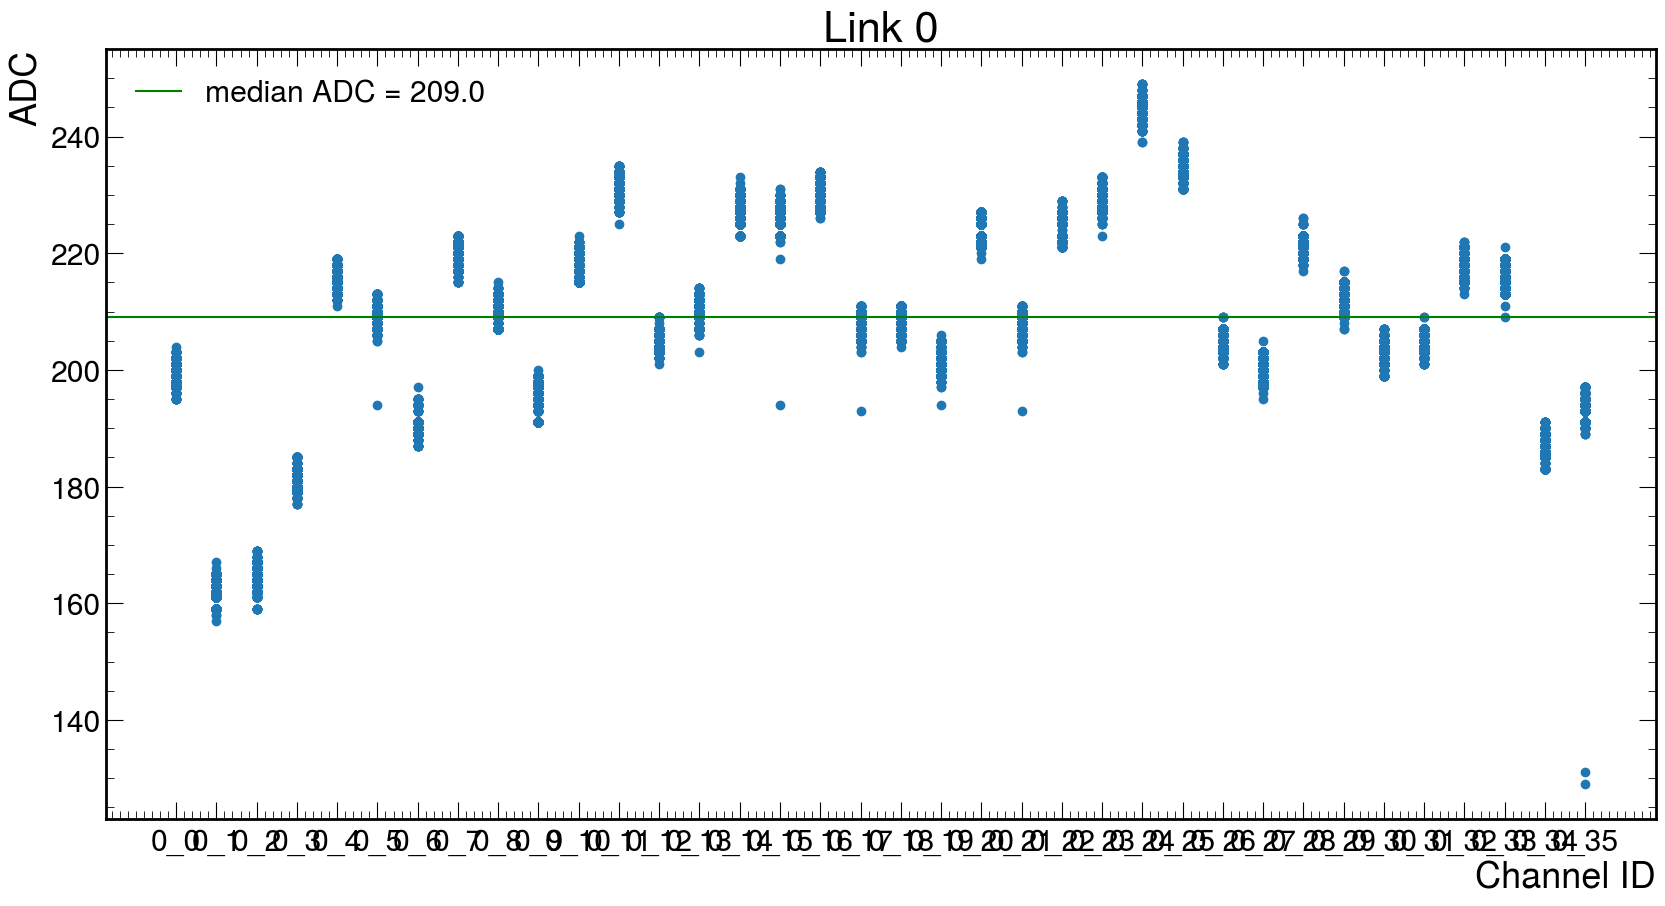

In [13]:
plt.figure(figsize=(20,10))
plt.scatter(link_0_norm.uid,link_0_norm.adc)
#plt.axhline(y=(link_0_norm['adc'].mean()), color='r', label = "mean ADC = " + str(link_0_norm['adc'].mean()) )
plt.axhline(y = (link_0_norm['adc'].median()), color = 'g', label = "median ADC = " +  str(link_0_norm['adc'].median()))
plt.legend(loc="upper left")
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 0")

In [14]:
print ("Link 1 median ADC is " + str(link_1_norm['adc'].median()) + " without calibration channels")
print ("Link 1 mean ADC is " + str(link_1_norm['adc'].mean()) + " without calibration channels")


Link 1 median ADC is 207.0 without calibration channels
Link 1 mean ADC is 209.0195361111111 without calibration channels


Text(0.5, 1.0, 'Link 1')

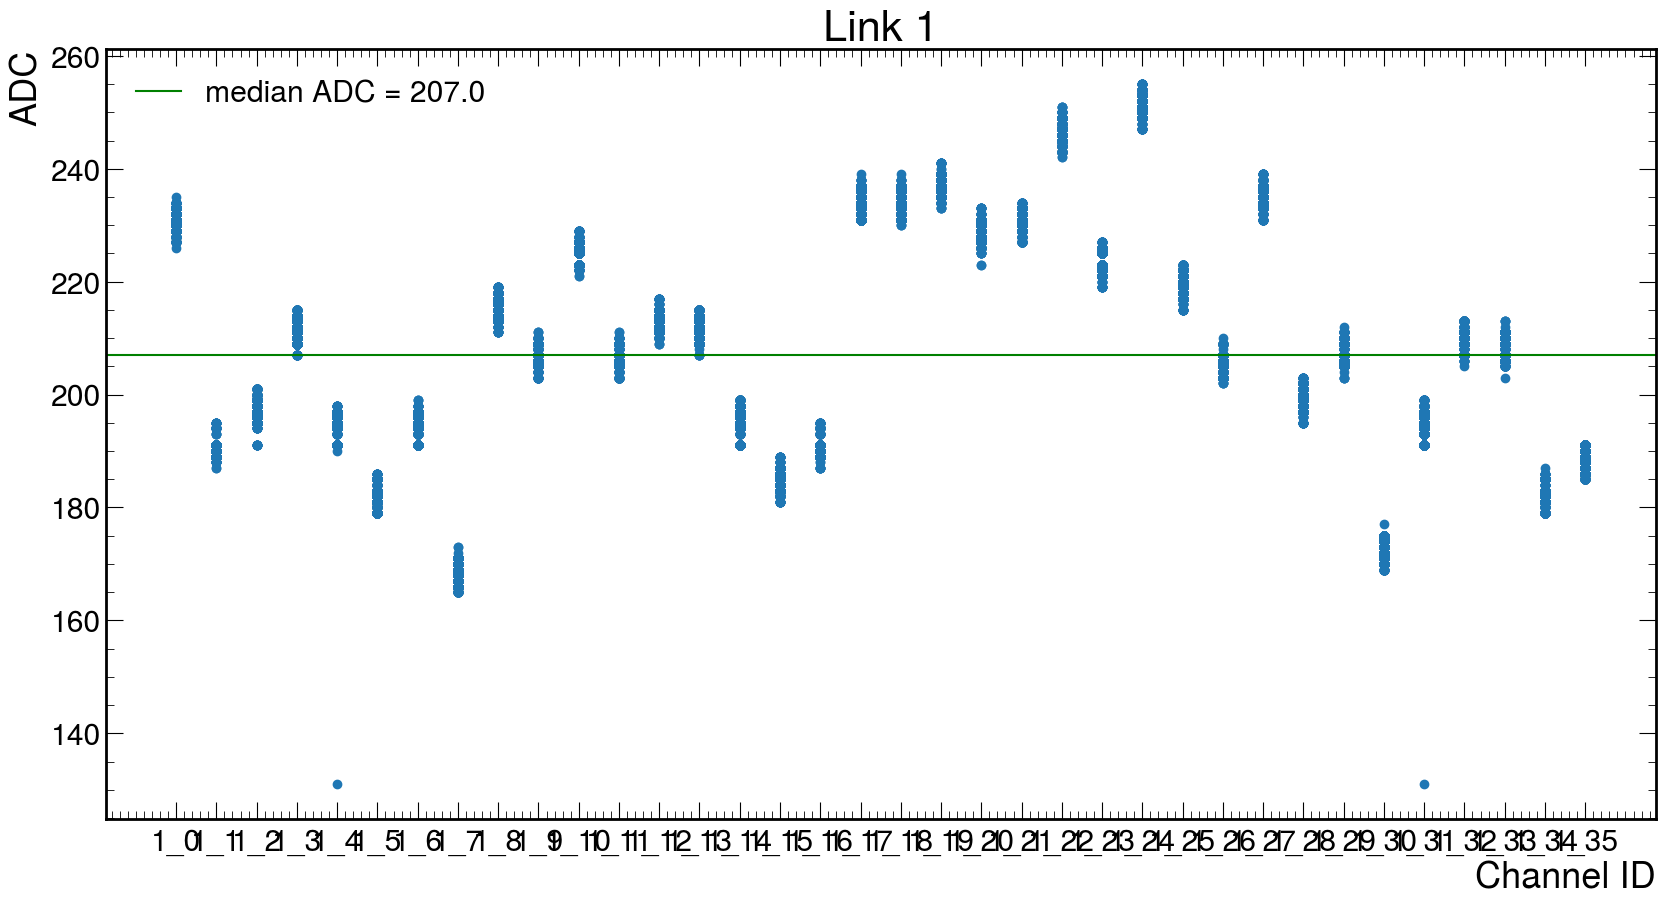

In [15]:
plt.figure(figsize=(20,10))
plt.scatter(link_1_norm.uid,link_1_norm.adc)
#plt.axhline(y=(link_1_norm['adc'].mean()), color='r', label = "mean ADC = " + str(link_1_norm['adc'].mean()) )
plt.axhline(y = (link_1_norm['adc'].median()), color = 'g', label = "median ADC = " +  str(link_1_norm['adc'].median()))
plt.legend(loc="upper left")
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 1")

Text(0.5, 1.0, 'Link 0 channel median')

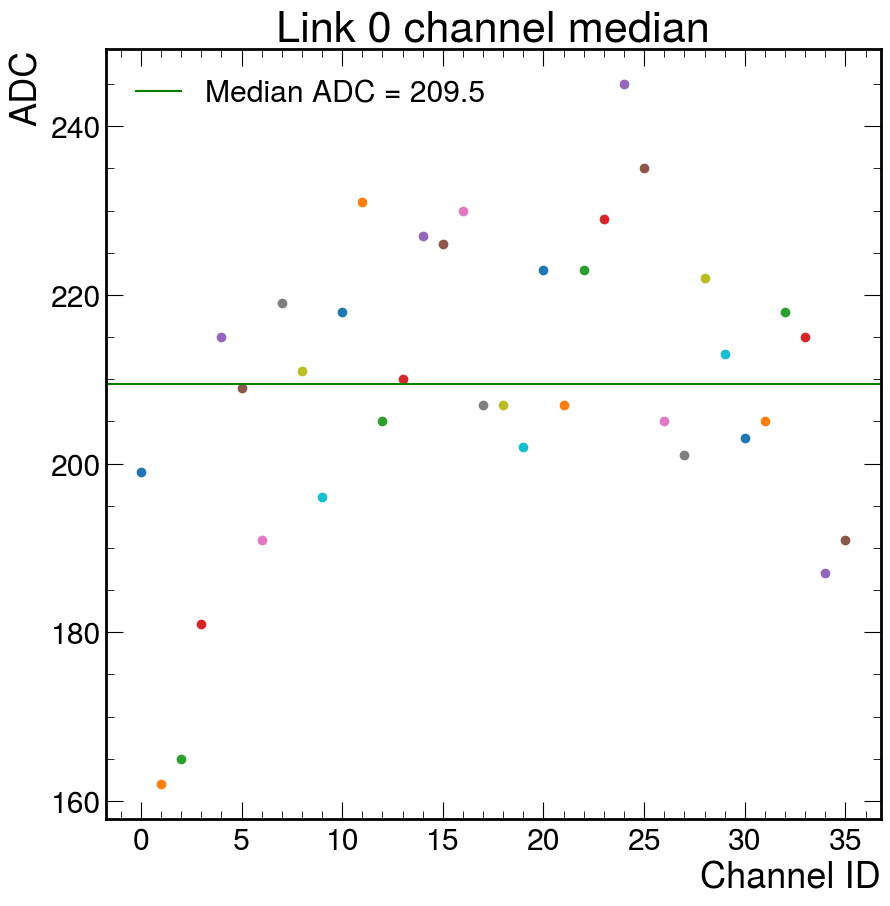

In [16]:
l0_ch_med = [] #the median ADC of each channel, in order from 0 to 35
#l0_ch_stddev = []
for i in range(36):
    median = link_0_norm[link_0_norm['channel'] == str(i)]['adc'].median()
    #ch_stddev = link_0_norm[link_0_norm['channel'] == str(i)]['adc'].std()

    plt.scatter(x = i, y = median )
    l0_ch_med.append(median)
    #l0_ch_stddev.append(ch_stddev)
link_0_median= np.median(l0_ch_med) #median of the median ADC list
#link_0_mean = np.mean(l0_ch_med)
#plt.axhline(y=link_0_mean, color='r', label ="Mean ADC = " + str(link_0_mean))
plt.axhline(y=link_0_median, color='g', label = "Median ADC = " + str(link_0_median))
plt.legend(loc="upper left")
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 0 channel median")


Text(0.5, 1.0, 'Link 1 channel median')

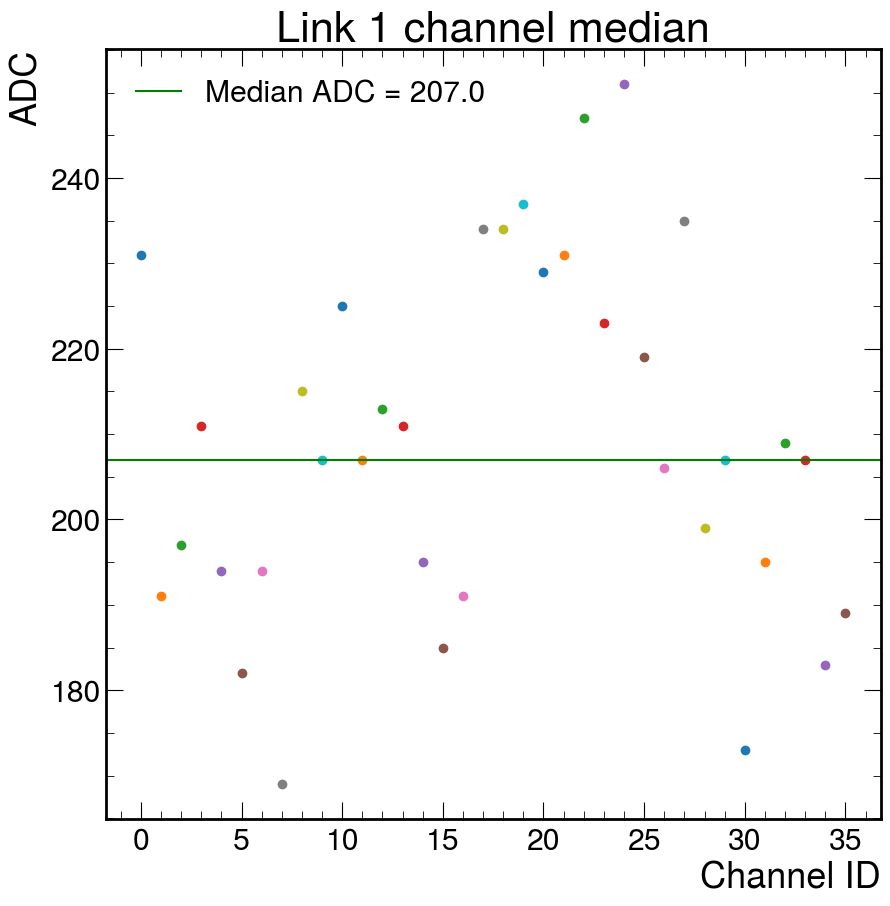

In [17]:
l1_ch_med = [] #the median ADC of each channel, in order from 0 to 35
#l1_ch_stddev = []
for i in range(36):
    median = link_1_norm[link_1_norm['channel'] == str(i)]['adc'].median()
    #if median <= 207:
        #print("CH_"+str(i)+ " has median lower than 207")
    #ch_stddev = link_1_norm[link_1_norm['channel'] == str(i)]['adc'].std()

    plt.scatter(x = i, y = median )
    l1_ch_med.append(median)
    #l1_ch_stddev.append(ch_stddev)
link_1_median= np.median(l1_ch_med) #median of the median ADC list
#link_1_mean = np.mean(l1_ch_med)
#plt.axhline(y=link_1_mean, color='r', label ="Mean ADC = " + str(link_1_mean))
plt.axhline(y=link_1_median, color='g', label = "Median ADC = " + str(link_1_median))

plt.legend(loc="upper left")
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 1 channel median")

In [18]:
high_triminv_ped = pd.read_csv('high_triminv_pedestal_10k.csv') #high trim_inv = 63, everything else is the same
high_triminv_ped['uid'] = high_triminv_ped['i_link'].astype(str)+'_'+high_triminv_ped['channel']
high_triminv_ped_norm = high_triminv_ped[high_triminv_ped['channel'] != 'calib']# removed the calibration channels to assess means/medians


In [19]:
highlink_0 = high_triminv_ped_norm[high_triminv_ped_norm['i_link'] ==0 ] # separated the pedestal run by the two link channels - the two halves seen in HGCROC Tuning slides
highlink_1 = high_triminv_ped_norm[high_triminv_ped_norm['i_link'] ==1 ]



In [20]:
highlink_0_med = [] #the median ADC of each channel, in order from 0 to 35
for i in range(36):
    median = highlink_0[highlink_0['channel'] == str(i)]['adc'].median()
    highlink_0_med.append(median)


In [21]:
highlink_1_med = [] #the median ADC of each channel, in order from 0 to 35
for i in range(36):
    median = highlink_1[highlink_1['channel'] == str(i)]['adc'].median()
    highlink_1_med.append(median)

In [22]:
 ## i want to find the value of the parameter trim_inv when ADC is at the median, my y value is the value of the parameter, triminv, for high_trim_inv, it's 63, for low/default it's 0

In [23]:
highlink_1_med[15]

229.0

In [24]:
l1_ch_med[15]

185.0

In [25]:
### so for channel x, 
adc_values = [l1_ch_med[15],highlink_1_med[15]]
trim_inv = [0,63]
link_1_median ## evaluate at this value

207.0

In [26]:
##imagine ADC is on the x axis, im looking for the corresponding y
round(np.interp(link_1_median, adc_values, trim_inv))

32

In [27]:
neg_high_dacb_ped = pd.read_csv('neg_high_dacb_pedestal_10k.csv') #sign_dac = 1, dacb = 31 for all channels, everything else is default
neg_high_dacb_ped['uid'] = neg_high_dacb_ped['i_link'].astype(str)+'_'+neg_high_dacb_ped['channel']
neg_high_dacb_ped = neg_high_dacb_ped[neg_high_dacb_ped['channel'] != 'calib']# removed the calibration channels to assess means/medians
dacb_link_0 = neg_high_dacb_ped[neg_high_dacb_ped['i_link'] ==0 ] # separated the pedestal run by the two link channels - the two halves seen in HGCROC Tuning slides
dacb_link_1 = neg_high_dacb_ped[neg_high_dacb_ped['i_link'] ==1 ]






Text(0.5, 1.0, 'Link 0 (neg high dacb test)')

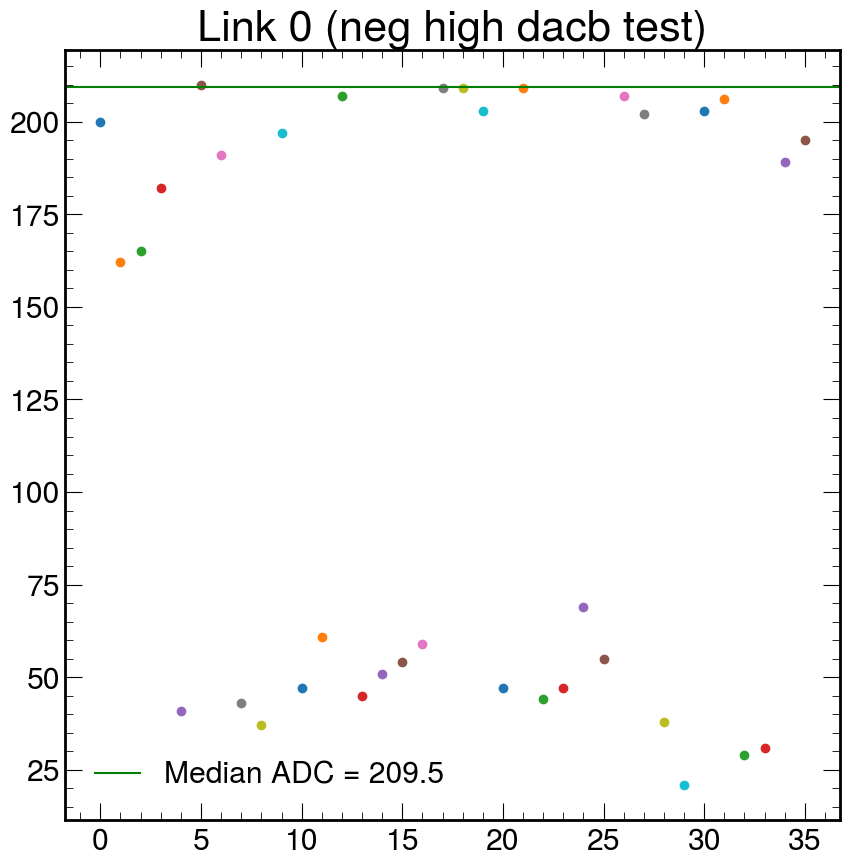

In [28]:
dacb_link_0_med = [] #the median ADC of each channel, in order from 0 to 35
for i in range(36):
    median = dacb_link_0[dacb_link_0['channel'] == str(i)]['adc'].median()
    dacb_link_0_med.append(median)
    plt.scatter(i, median)
plt.axhline(y=link_0_median, color='g', label = "Median ADC = " + str(link_0_median))
plt.legend(loc="best")
plt.title("Link 0 (neg high dacb test)")

Text(0.5, 1.0, 'Link 1 (neg high dacb test)')

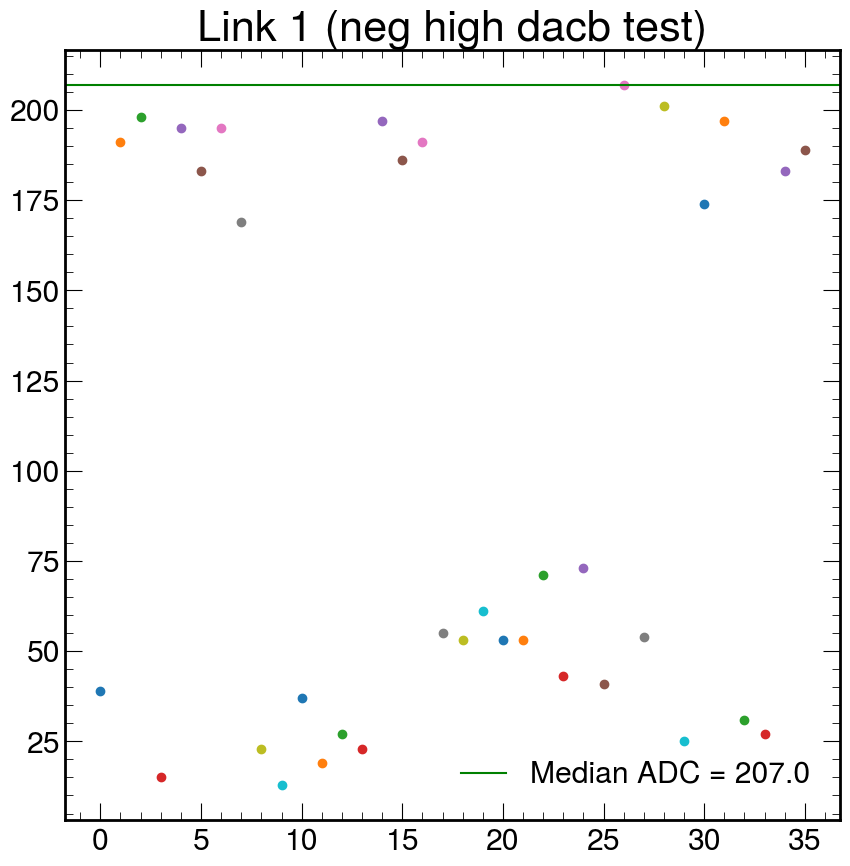

In [29]:
dacb_link_1_med = [] #the median ADC of each channel, in order from 0 to 35
for i in range(36):
    median = dacb_link_1[dacb_link_1['channel'] == str(i)]['adc'].median()
    dacb_link_1_med.append(median)
    plt.scatter(i,median)
plt.axhline(y=link_1_median, color='g', label = "Median ADC = " + str(link_1_median))
plt.legend(loc="best")
plt.title("Link 1 (neg high dacb test)")
    

In [30]:
adc_values = [dacb_link_1_med[26],l1_ch_med[26]]
dacb = [31,0]
link_0_median ## evaluate at this value


209.5

In [31]:
adc_values = [dacb_link_0_med[7],l0_ch_med[7]]
dacb = [31,0]
link_0_median ## evaluate at this value


209.5

In [32]:
channels_settings = {}
#default_triminv= 0
#default_dacb = 0
#default_sign_dac = 0
neg_sign_dac = 1
trim_inv = [0,63]
dacb = [31,0]
#dacb_channels = []
for a in range(36):
    name = "CH_" + str(a)
    if l0_ch_med[a] < link_0_median :
        adc_values = [l0_ch_med[a],highlink_0_med[a]]
        new_triminv = round(np.interp(link_0_median, adc_values, trim_inv))
        channels_settings[name] ={"TRIM_INV" : new_triminv}
    else:
        adc_values = [dacb_link_0_med[a], l0_ch_med[a]]
        new_dacb = round(np.interp(link_0_median, adc_values, dacb))
        channels_settings[name] ={"DACB" : new_dacb, "SIGN_DAC": neg_sign_dac}
for b in range(36):
    name = "CH_" + str(b+36)
    if l1_ch_med[b] < link_1_median :
        adc_values = [l1_ch_med[b],highlink_1_med[b]]
        new_triminv = round(np.interp(link_1_median, adc_values, trim_inv))
        channels_settings[name] ={"TRIM_INV" : new_triminv}
    else:
        adc_values = [dacb_link_1_med[b],l1_ch_med[b]]
        new_dacb = round(np.interp(link_1_median, adc_values, dacb))
        channels_settings[name] ={"DACB" : new_dacb, "SIGN_DAC": neg_sign_dac}
            

In [69]:
channels_settings_med_150 = {}
#default_triminv= 0
#default_dacb = 0
#default_sign_dac = 0
median = 50 # trying for a median at 100 instead
neg_sign_dac = 1
trim_inv = [0,63]
dacb = [31,0]
#dacb_channels = []
for a in range(36):
    name = "CH_" + str(a)
    if l0_ch_med[a] < median :
        adc_values = [l0_ch_med[a],highlink_0_med[a]]
        new_triminv = round(np.interp(median, adc_values, trim_inv))
        channels_settings_med_150[name] ={"TRIM_INV" : new_triminv}
    else:
        adc_values = [dacb_link_0_med[a], l0_ch_med[a]]
        new_dacb = round(np.interp(median, adc_values, dacb))
        channels_settings_med_150[name] ={"DACB" : new_dacb, "SIGN_DAC": neg_sign_dac}
for b in range(36):
    name = "CH_" + str(b+36)
    if l1_ch_med[b] < median :
        adc_values = [l1_ch_med[b],highlink_1_med[b]]
        new_triminv = round(np.interp(median, adc_values, trim_inv))
        channels_settings_med_150[name] ={"TRIM_INV" : new_triminv}
    else:
        adc_values = [dacb_link_1_med[b],l1_ch_med[b]]
        new_dacb = round(np.interp(median, adc_values, dacb))
        channels_settings_med_150[name] ={"DACB" : new_dacb, "SIGN_DAC": neg_sign_dac}
channels_settings_med_150['REFERENCEVOLTAGE_0'] ={'INV_VREF' : 416}
channels_settings_med_150['REFERENCEVOLTAGE_1'] ={'INV_VREF' : 416}
            

In [70]:
channels_settings_med_150

{'CH_0': {'DACB': 31, 'SIGN_DAC': 1},
 'CH_1': {'DACB': 31, 'SIGN_DAC': 1},
 'CH_2': {'DACB': 31, 'SIGN_DAC': 1},
 'CH_3': {'DACB': 31, 'SIGN_DAC': 1},
 'CH_4': {'DACB': 29, 'SIGN_DAC': 1},
 'CH_5': {'DACB': 31, 'SIGN_DAC': 1},
 'CH_6': {'DACB': 31, 'SIGN_DAC': 1},
 'CH_7': {'DACB': 30, 'SIGN_DAC': 1},
 'CH_8': {'DACB': 29, 'SIGN_DAC': 1},
 'CH_9': {'DACB': 31, 'SIGN_DAC': 1},
 'CH_10': {'DACB': 30, 'SIGN_DAC': 1},
 'CH_11': {'DACB': 31, 'SIGN_DAC': 1},
 'CH_12': {'DACB': 31, 'SIGN_DAC': 1},
 'CH_13': {'DACB': 30, 'SIGN_DAC': 1},
 'CH_14': {'DACB': 31, 'SIGN_DAC': 1},
 'CH_15': {'DACB': 31, 'SIGN_DAC': 1},
 'CH_16': {'DACB': 31, 'SIGN_DAC': 1},
 'CH_17': {'DACB': 31, 'SIGN_DAC': 1},
 'CH_18': {'DACB': 31, 'SIGN_DAC': 1},
 'CH_19': {'DACB': 31, 'SIGN_DAC': 1},
 'CH_20': {'DACB': 30, 'SIGN_DAC': 1},
 'CH_21': {'DACB': 31, 'SIGN_DAC': 1},
 'CH_22': {'DACB': 30, 'SIGN_DAC': 1},
 'CH_23': {'DACB': 30, 'SIGN_DAC': 1},
 'CH_24': {'DACB': 31, 'SIGN_DAC': 1},
 'CH_25': {'DACB': 31, 'SIGN_DAC': 

In [71]:
with open ('med_150_channel_settings.yaml', 'w') as f:
    yaml.dump(channels_settings_med_150, f)

In [32]:
#with open ('aligned_dacb_trim_inv_settings_v3.yaml', 'w') as f:
    #yaml.dump(channels_settings, f)

Visualization of Version 3 that worked well

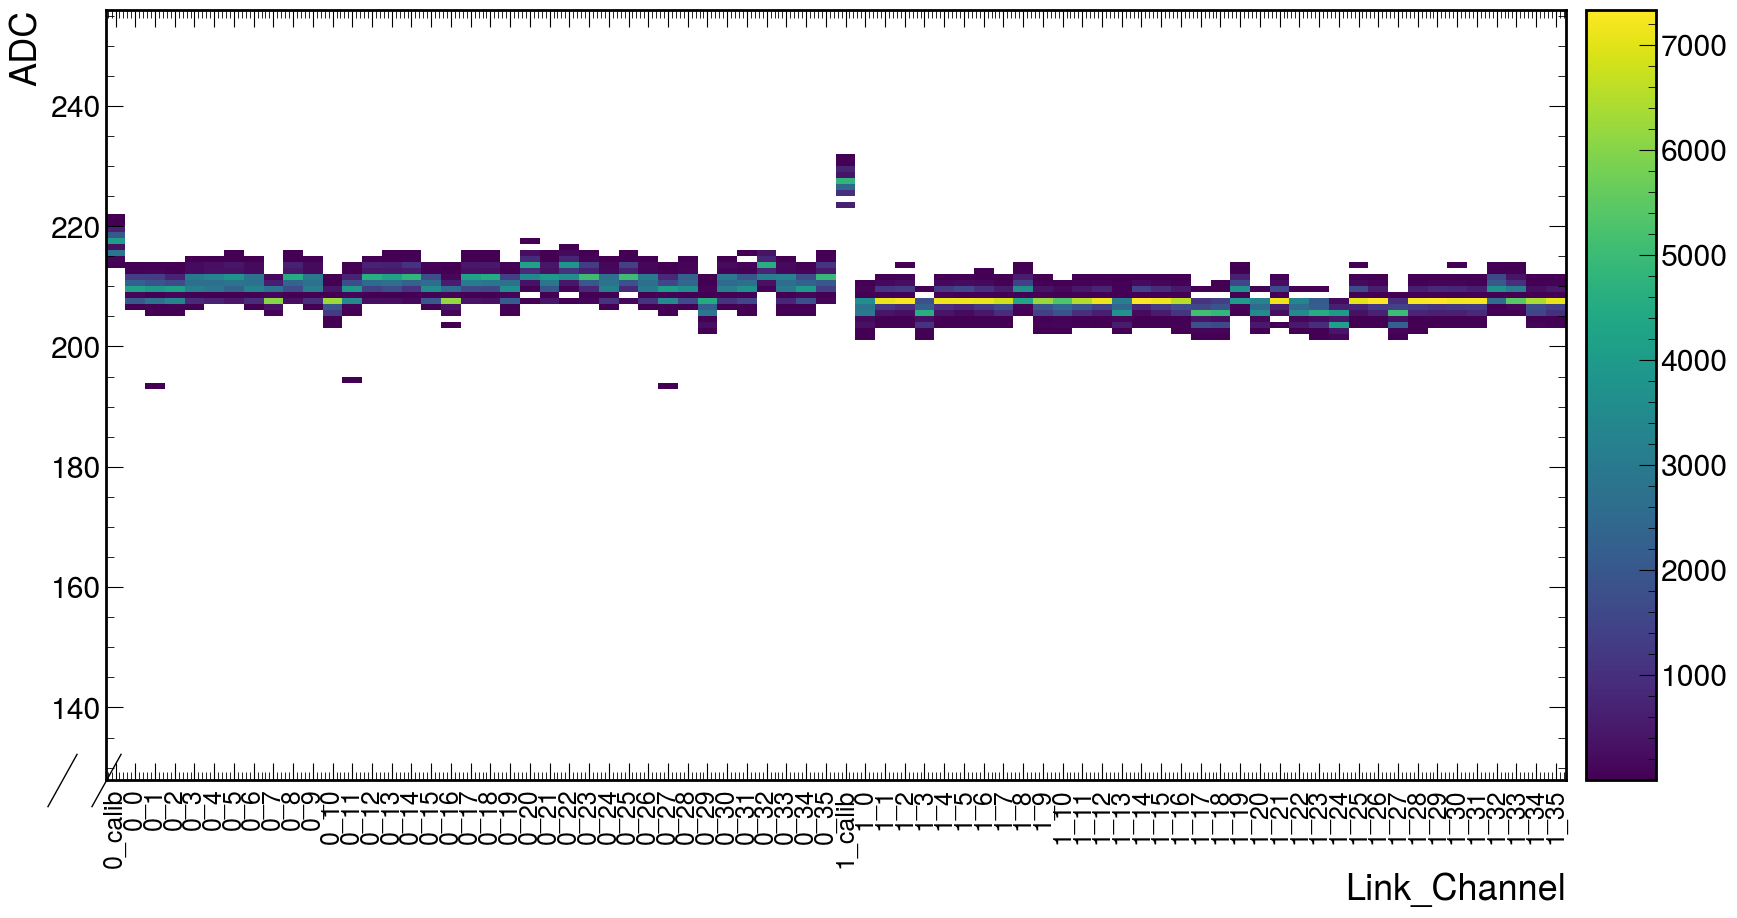

In [63]:
## version 3 has worked 
pedestal = pd.read_csv('align_ped_10k_v3.csv')
pedestal['uid'] = pedestal['i_link'].astype(str)+'_'+pedestal['channel']
fill_and_plot_all_channels('adc','ADC',128,256)

In [64]:
link_0 = pedestal[pedestal['i_link'] ==0] # separated the pedestal run by the two link channels - the two halves seen in HGCROC Tuning slides
link_1 = pedestal[pedestal['i_link'] ==1]
link_0_norm =link_0[link_0['channel'] != 'calib'] # removed the calibration channels to assess means/medians
link_1_norm =link_1[link_1['channel'] != 'calib']

Text(0.5, 1.0, 'Link 0 channel median')

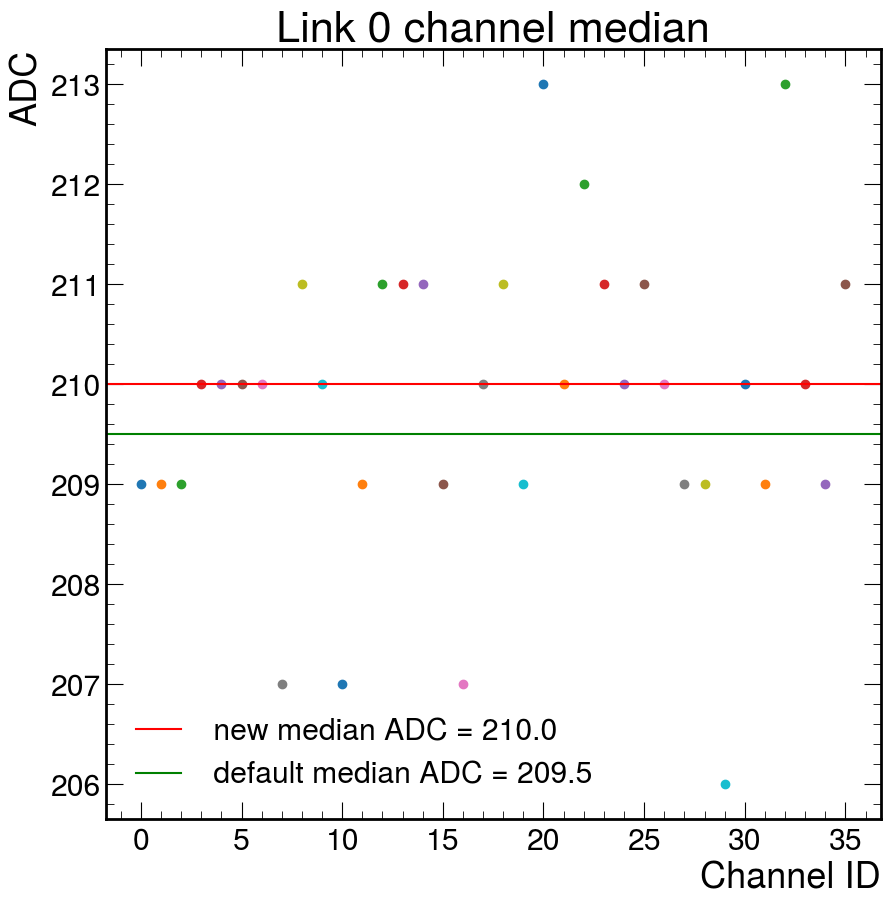

In [65]:
l0_ch_med = [] #the median ADC of each channel, in order from 0 to 35
l0_ch_stddev = []
for i in range(36):
    median = link_0_norm[link_0_norm['channel'] == str(i)]['adc'].median()
    #ch_stddev = link_0_norm[link_0_norm['channel'] == str(i)]['adc'].std()

    plt.scatter(x = i, y = median )
    l0_ch_med.append(median)
    #l0_ch_stddev.append(ch_stddev)
link_0_median= np.median(l0_ch_med) #median of the median ADC list
plt.axhline(y = link_0_median, color = 'r', label = " new median ADC = "+str(link_0_median))
plt.axhline(y = 209.5, color = 'g', label = " default median ADC = 209.5")
plt.legend(loc="best")
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 0 channel median")


Text(0.5, 1.0, 'Link 1 channel median')

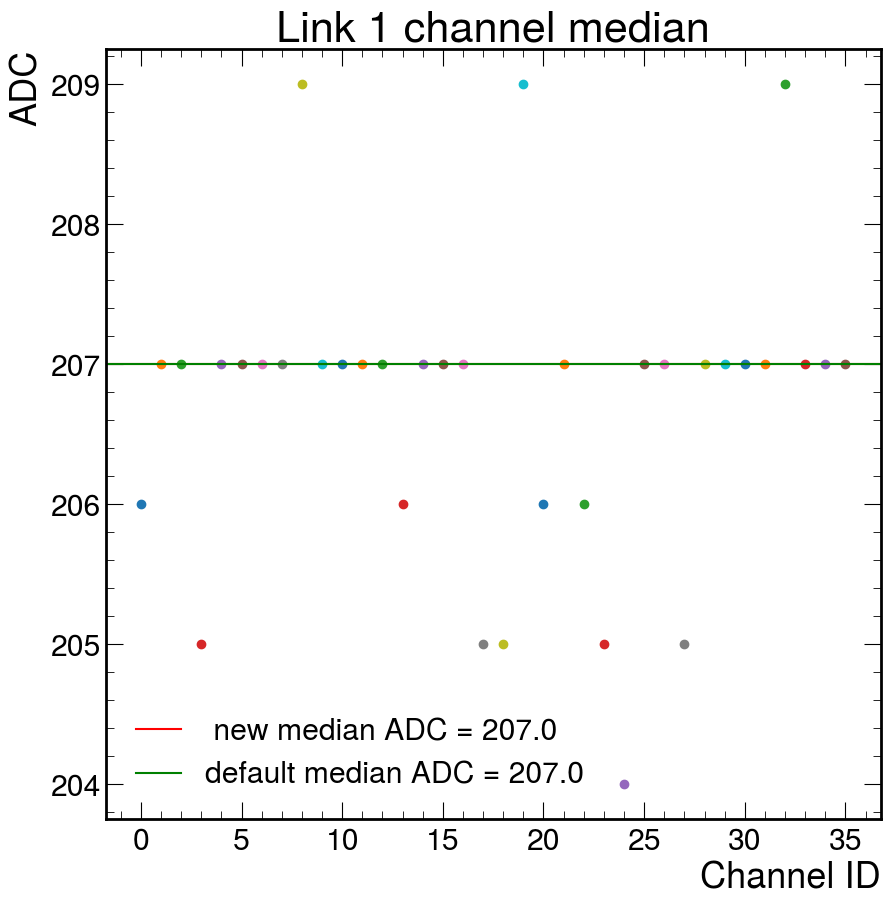

In [67]:
l1_ch_med = [] #the median ADC of each channel, in order from 0 to 35
#l1_ch_stddev = []
for i in range(36):
    median = link_1_norm[link_1_norm['channel'] == str(i)]['adc'].median()
    #if median <= 207:
        #print("CH_"+str(i)+ " has median lower than 207")
    #ch_stddev = link_1_norm[link_1_norm['channel'] == str(i)]['adc'].std()

    plt.scatter(x = i, y = median )
    l1_ch_med.append(median)
    #l1_ch_stddev.append(ch_stddev)
link_1_median= np.median(l1_ch_med) #median of the median ADC list
plt.axhline(y = link_1_median, color = 'r', label = " new median ADC = "+ str(link_1_median))
plt.axhline(y = 207.0, color = 'g', label = "default median ADC = 207.0")
plt.legend(loc="best")
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 1 channel median")

In [1]:
# {"parameter_points_file":"link_0_inv_vref_scan_settings.csv","channel":0,"nevents_per_point":10,"trigger":"PEDESTAL","scan_wide_params":{}} REFERENCEVOLTAGE_0

inv_vref_test = pd.read_csv('link_0_inv_vref_scan_settings_20250710_170538.csv')

NameError: name 'pd' is not defined

In [36]:
inv_vref_test

,INV_VREF,Tp,Tc,adc_tm1,adc,tot,toa
0,0,False,False,527,527,-1,0
1,0,False,False,527,527,-1,0
2,0,False,False,527,527,-1,0
3,0,False,False,527,527,-1,0
4,0,False,False,527,527,-1,0
...,...,...,...,...,...,...,...
2725,600,False,False,11,11,-1,0
2726,600,False,False,10,10,-1,0
2727,600,False,False,12,11,-1,0
2728,600,False,False,11,11,-1,0


In [37]:
y = inv_vref_test.adc
x = inv_vref_test.INV_VREF

In [17]:
type(x)

pandas.core.series.Series

In [18]:
np.interp(50,x, y)

517.625

Text(0.5, 1.0, 'Link 0 - channel 0')

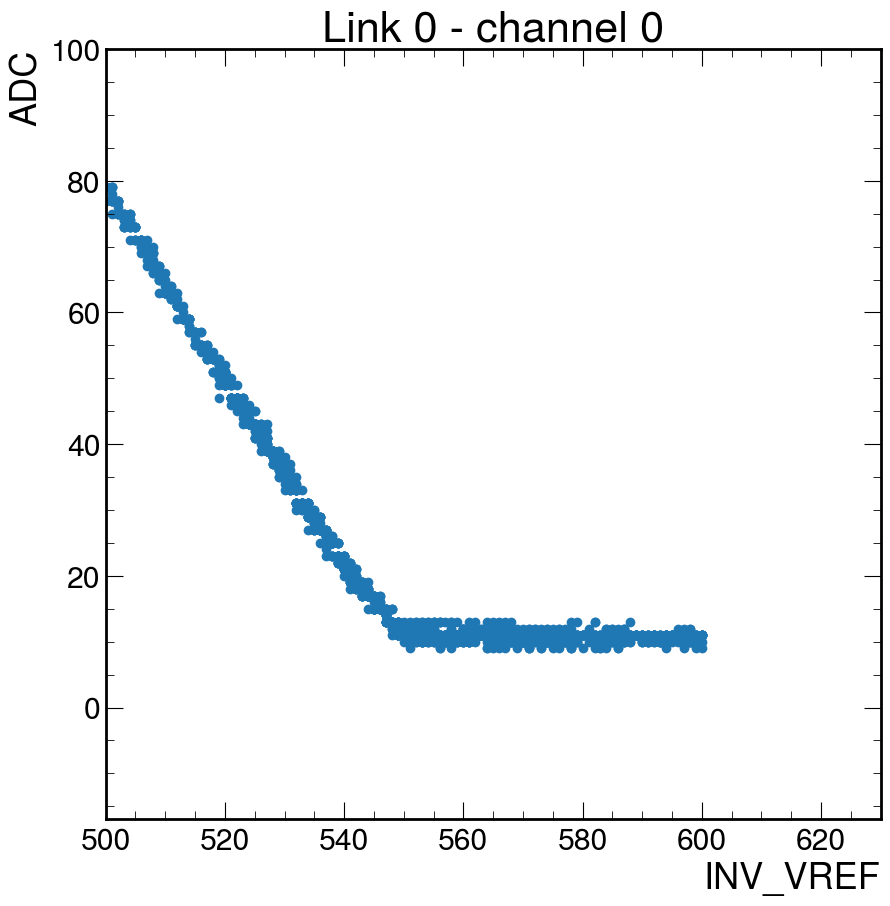

In [38]:
plt.scatter(inv_vref_test.INV_VREF, inv_vref_test.adc)
#plt.axhline(y=50, color='g')
#plt.axvline(x=520, color='g')
plt.ylim(top = 100)
plt.xlim(left = 500)
plt.xlabel("INV_VREF")
plt.ylabel("ADC")
plt.title("Link 0 - channel 0")

In [39]:
inv_vref_test[(inv_vref_test.adc>=49) & (inv_vref_test.adc <=51)]

,INV_VREF,Tp,Tc,adc_tm1,adc,tot,toa
1300,518,False,False,55,51,-1,0
1306,518,False,False,53,51,-1,0
1307,518,False,False,53,51,-1,0
1312,519,False,False,51,51,-1,0
1314,519,False,False,49,51,-1,0
1316,519,False,False,52,51,-1,0
1317,519,False,False,50,51,-1,0
1318,519,False,False,52,51,-1,0
1319,519,False,False,51,51,-1,0
1320,520,False,False,51,49,-1,0


In [41]:
list(inv_vref_test.INV_VREF[(inv_vref_test.adc>=49) & (inv_vref_test.adc <=51)])

[518,
 518,
 518,
 519,
 519,
 519,
 519,
 519,
 519,
 520,
 520,
 520,
 520,
 520,
 520,
 520,
 520,
 520,
 521,
 521,
 522,
 519,
 519,
 519,
 519,
 519,
 519,
 519,
 519,
 520,
 520,
 520,
 520,
 520,
 520,
 520,
 520,
 520,
 520,
 521,
 521,
 521]

In [42]:
np.round(mean(list(inv_vref_test.INV_VREF[(inv_vref_test.adc>=49) & (inv_vref_test.adc <=51)]))) #LINK 0 mean inv_vref that'll give us 50 +/- 1 for adc

520.0

In [43]:
# {"parameter_points_file":"link_1_inv_vref_scan_setting.csv","channel":71,"nevents_per_point":10,"trigger":"PEDESTAL","scan_wide_params":{}} REFERENCEVOLTAGE_1.

inv_vref_test = pd.read_csv('link_1_inv_vref_scan_setting_20250710_170659.csv')

Text(0.5, 1.0, 'Link 1 - channel 71')

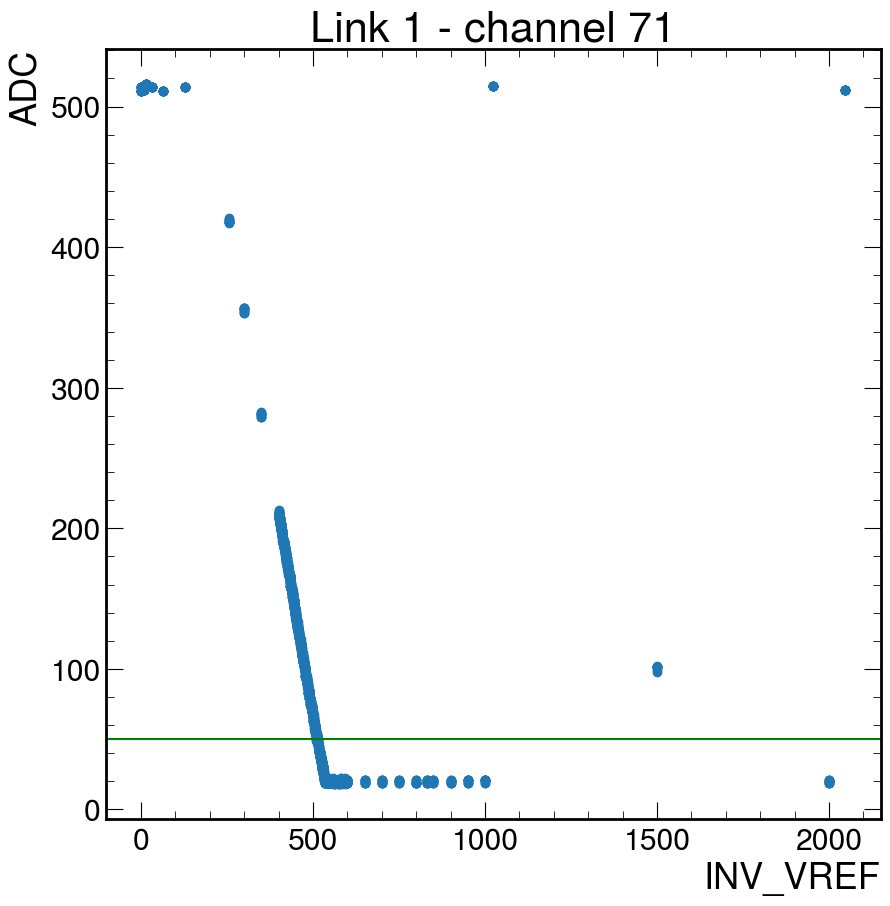

In [44]:
plt.scatter(inv_vref_test.INV_VREF, inv_vref_test.adc)
#plt.axhline(y=50, color='g')
#plt.axvline(x=520, color='g')
#plt.ylim(top = 100)
#plt.xlim(left = 500)
plt.xlabel("INV_VREF")
plt.ylabel("ADC")
plt.title("Link 1 - channel 71")

In [45]:
inv_vref_test[(inv_vref_test.adc>=49) & (inv_vref_test.adc <=51)]

,INV_VREF,Tp,Tc,adc_tm1,adc,tot,toa
1221,510,False,False,51,50,-1,0
1222,510,False,False,53,50,-1,0
1223,510,False,False,51,51,-1,0
1224,510,False,False,49,49,-1,0
1228,510,False,False,51,51,-1,0
1229,510,False,False,51,51,-1,0
1230,511,False,False,51,50,-1,0
1231,511,False,False,51,50,-1,0
1232,511,False,False,50,50,-1,0
1233,511,False,False,51,49,-1,0


In [46]:
np.round(mean(list(inv_vref_test.INV_VREF[(inv_vref_test.adc>=49) & (inv_vref_test.adc <=51)]))) #LINK 1 mean inv_vref that'll give us 50 +/- 1 for adc

512.0

In [75]:
# {"parameter_points_file":"link_1_noinv_vref_scan_setting.csv","channel":71,"nevents_per_point":1,"trigger":"PEDESTAL","scan_wide_params":{}}REFERENCEVOLTAGE_1.NOINV_VREF
noinv_vref_test = pd.read_csv('link_1_noinv_vref_scan_setting_20250707_192923.csv')

Text(0, 1, 'ADC')

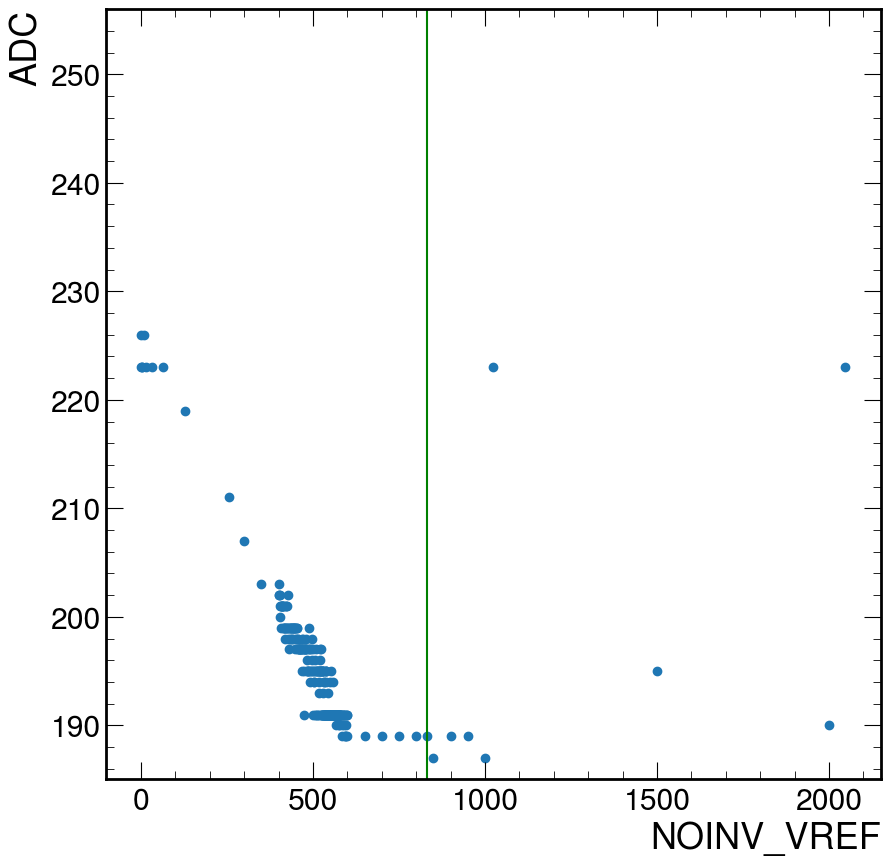

In [90]:
plt.scatter(noinv_vref_test.NOINV_VREF, noinv_vref_test.adc)
#plt.axhline(y=200, color='g')
plt.axvline(x=832, color='g')
plt.ylim(top = 256)
#plt.xlim(left = 500)
plt.xlabel("NOINV_VREF")
plt.ylabel("ADC")

In [94]:
noinv_vref_test[(noinv_vref_test.adc>=206) & (noinv_vref_test.adc <=208)]

,NOINV_VREF,Tp,Tc,adc_tm1,adc,tot,toa
10,300,False,False,207,207,-1,0


In [91]:
np.round(mean(list(noinv_vref_test.NOINV_VREF[(noinv_vref_test.adc>=206) & (noinv_vref_test.adc <=208)])))

300

In [95]:
# {"parameter_points_file":"link_1_inv_vref_scan_setting.csv","channel":71,"nevents_per_point":1,"trigger":"PEDESTAL","scan_wide_params":{"REFERENCEVOLTAGE_1":{"NOINV_VREF":300}}}
#REFERENCEVOLTAGE_1.INV_VREF,
test = pd.read_csv('link_1_inv_vref_scan_setting_20250707_200426.csv')

Text(0, 1, 'ADC')

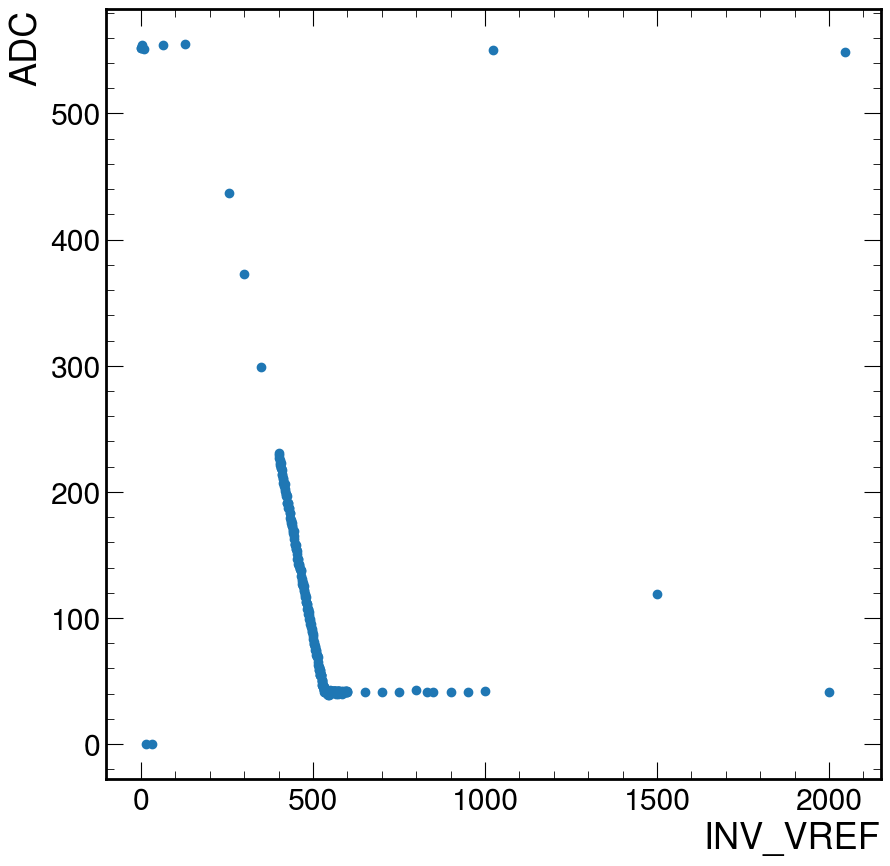

In [96]:
plt.scatter(test.INV_VREF, test.adc)
#plt.axhline(y=200, color='g')
#plt.axvline(x=832, color='g')
#plt.ylim(top = 256)
#plt.xlim(left = 500)
plt.xlabel("INV_VREF")
plt.ylabel("ADC")

In [97]:
test[(test.adc>=49) & (test.adc <=51)]

,INV_VREF,Tp,Tc,adc_tm1,adc,tot,toa
137,525,False,False,53,51,-1,0
138,526,False,False,51,50,-1,0
197,525,False,False,51,51,-1,0
198,526,False,False,50,49,-1,0


In [48]:
channels_settings['REFERENCEVOLTAGE_0'] ={'INV_VREF' : 520}
channels_settings['REFERENCEVOLTAGE_1'] ={'INV_VREF' : 512}

In [50]:
with open ('vref_settings_v4.yaml', 'w') as f:
    yaml.dump(channels_settings, f)

In [51]:
channels_settings

{'CH_0': {'TRIM_INV': 14},
 'CH_1': {'TRIM_INV': 61},
 'CH_2': {'TRIM_INV': 58},
 'CH_3': {'TRIM_INV': 37},
 'CH_4': {'DACB': 1, 'SIGN_DAC': 1},
 'CH_5': {'TRIM_INV': 1},
 'CH_6': {'TRIM_INV': 24},
 'CH_7': {'DACB': 2, 'SIGN_DAC': 1},
 'CH_8': {'DACB': 0, 'SIGN_DAC': 1},
 'CH_9': {'TRIM_INV': 18},
 'CH_10': {'DACB': 2, 'SIGN_DAC': 1},
 'CH_11': {'DACB': 4, 'SIGN_DAC': 1},
 'CH_12': {'TRIM_INV': 6},
 'CH_13': {'DACB': 0, 'SIGN_DAC': 1},
 'CH_14': {'DACB': 3, 'SIGN_DAC': 1},
 'CH_15': {'DACB': 3, 'SIGN_DAC': 1},
 'CH_16': {'DACB': 4, 'SIGN_DAC': 1},
 'CH_17': {'TRIM_INV': 3},
 'CH_18': {'TRIM_INV': 3},
 'CH_19': {'TRIM_INV': 10},
 'CH_20': {'DACB': 2, 'SIGN_DAC': 1},
 'CH_21': {'TRIM_INV': 3},
 'CH_22': {'DACB': 2, 'SIGN_DAC': 1},
 'CH_23': {'DACB': 3, 'SIGN_DAC': 1},
 'CH_24': {'DACB': 6, 'SIGN_DAC': 1},
 'CH_25': {'DACB': 4, 'SIGN_DAC': 1},
 'CH_26': {'TRIM_INV': 6},
 'CH_27': {'TRIM_INV': 11},
 'CH_28': {'DACB': 2, 'SIGN_DAC': 1},
 'CH_29': {'DACB': 1, 'SIGN_DAC': 1},
 'CH_30': {'TRIM